In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics
import math

In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/heart.csv'
df=pd.read_csv(file_path)
print(df)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


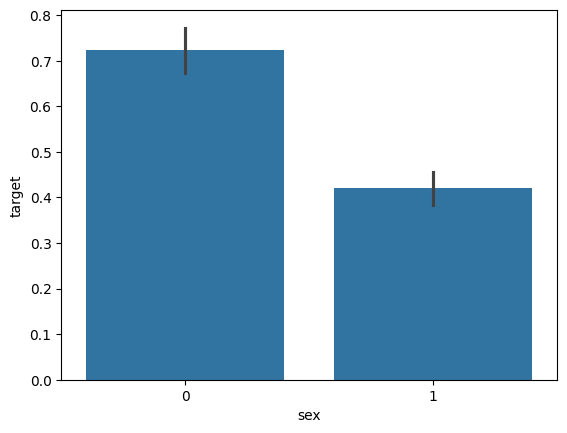

In [ ]:
sns.barplot(data=df,x='sex',y='target')
plt.show()

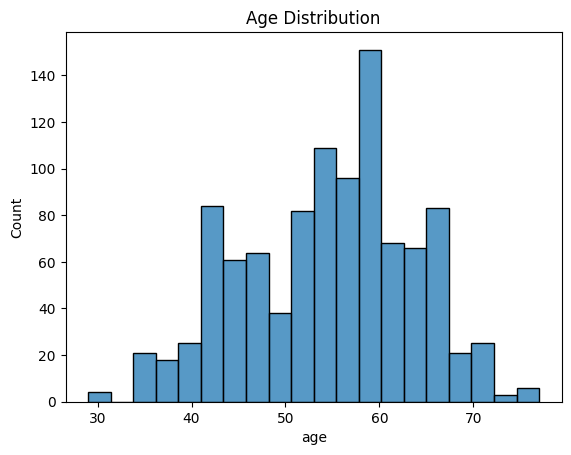

In [ ]:
sns.histplot(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

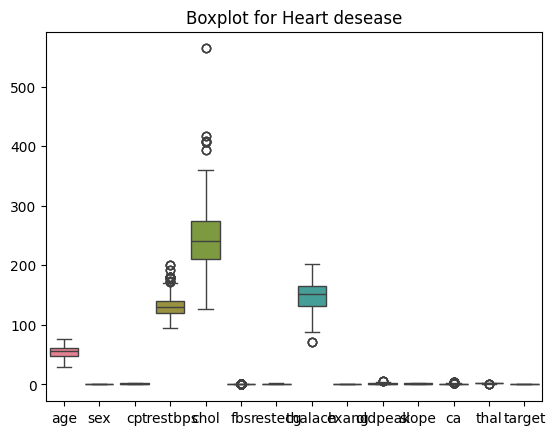

In [ ]:
sns.boxplot(data=df )
plt.title('Boxplot for Heart desease')
plt.show()

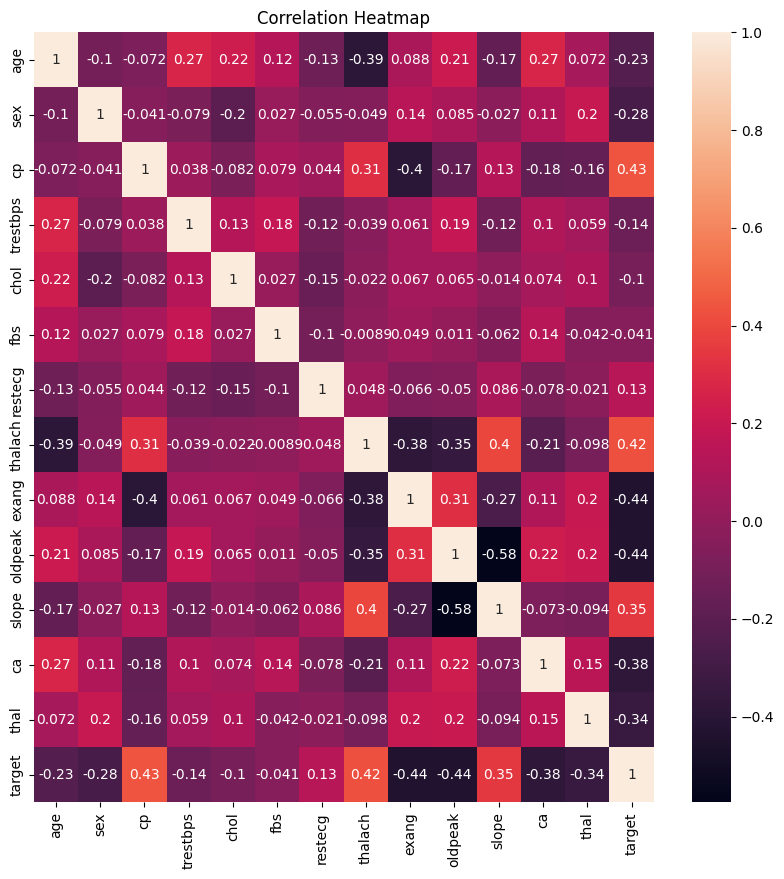

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

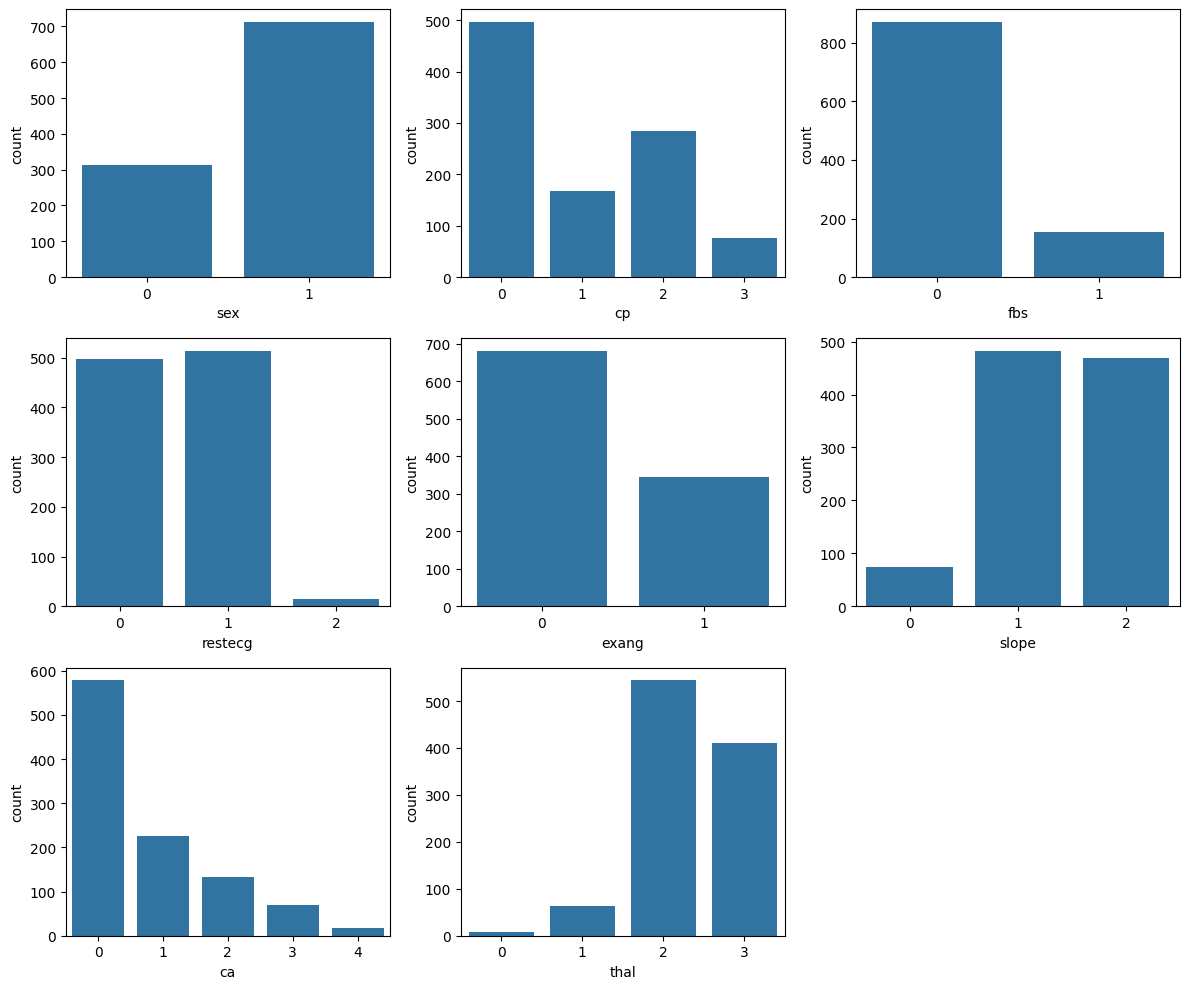

In [ ]:
cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
plt.figure(figsize=(12,10))
for i,col in enumerate(cat_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(data=df,x=df[col])
plt.tight_layout()
plt.show()

In [ ]:
x=df.drop('target',axis=1)
y=df['target']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

rf=ensemble.RandomForestClassifier(random_state=0)
rf.fit(x_train,y_train)

lr=LogisticRegression()
lr.fit(x_train,y_train)

rf=DecisionTreeClassifier()
rf.fit(x_train,y_train)

rf=KNeighborsClassifier()
rf.fit(x_train,y_train)

rf=SVC()
rf.fit(x_train,y_train)

SVC()

In [ ]:
y_pred=rf.predict(x_test)
y_pred
y_pred_lr=lr.predict(x_test)
y_pred_lr
y_pred_dt=rf.predict(x_test)
y_pred_dt
y_pred_knn=rf.predict(x_test)
y_pred_knn
y_pred_svm=rf.predict(x_test)
y_pred_svm

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0])

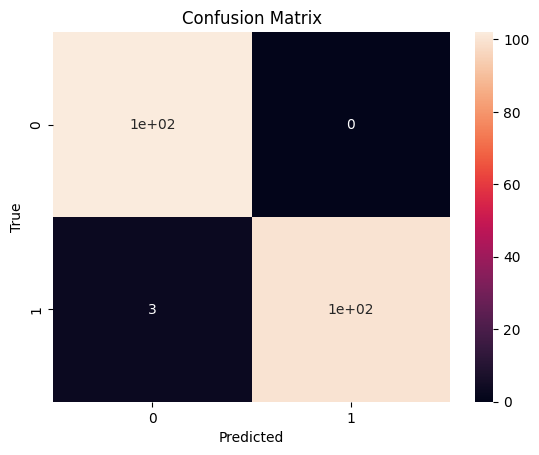

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print('Random Forest accuracy')
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("KNN accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("SVM accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Random Forest accuracy
Accuracy: 0.9853658536585366


Random Forest 0.8878048780487805
Logitistic Regression 0.7951219512195122
Decision Tree 0.8878048780487805
KNN 0.8878048780487805
SVM 0.8878048780487805


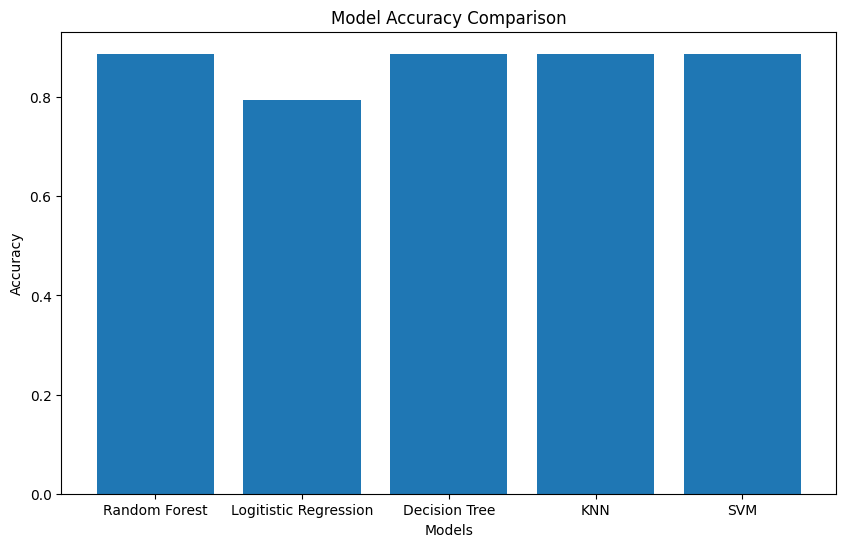

Best Model: Random Forest


In [ ]:
import sklearn as sk
from sklearn.metrics import accuracy_score
print('Random Forest', accuracy_score(y_test, y_pred))
print('Logitistic Regression', accuracy_score(y_test, y_pred_lr))
print('Decision Tree', accuracy_score(y_test, y_pred_dt))
print('KNN', accuracy_score(y_test, y_pred_knn))
print('SVM', accuracy_score(y_test, y_pred_svm))
model_accuracy = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'Logitistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm)
}
plt.figure(figsize=(10,6))
plt.bar(model_accuracy.keys(), model_accuracy.values())
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()
best_model = max(model_accuracy, key=model_accuracy.get)
print("Best Model:", best_model)

In [ ]:
def predict_outcome():
  featuress=[]
  for col in x.columns:
    value=float(input(f"Enter the value for {col}: "))
    featuress.append(value)

  featuress=np.array(featuress).reshape(1,-1)
  featuress=scaler.transform(featuress)
  prediction=rf.predict(featuress)
  if (prediction[0]==1):
    print("HEART DESEASE +POSITIVE")
  else :
    print("HEART DESEASE -NEGATIVE")

In [ ]:
predict_outcome()

Enter the value for age: 50
Enter the value for sex: 1
Enter the value for cp: 2
Enter the value for trestbps: 3
Enter the value for chol: 4
Enter the value for fbs: 2
Enter the value for restecg: 5
Enter the value for thalach: 3
Enter the value for exang: 2
Enter the value for oldpeak: 2
Enter the value for slope: 4
Enter the value for ca: 3
Enter the value for thal: 2
HEART DESEASE -NEGATIVE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
